# Analysis

My data analysis is seperated into 4 chapter - __Revenue, Products, Traffic and Sessions__. <br>



## Revenue Analysis

Here I discover the health of my test business.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd


df_sales = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sales.csv")
df_sessions = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sessions.csv")

print(df_sales.shape)
print(df_sessions.shape)

(40025, 14)
(472871, 11)


__Monthly Revenue__

In [6]:
df_sales["created_at"] = pd.to_datetime(df_sales["created_at"])

df_sales["year_month"] = df_sales["created_at"].dt.to_period("M")


monthly_revenue = (df_sales.groupby("year_month").agg
                   (total_revenue = ("price_usd", "sum"), 
                    total_cost = ("cogs_usd", "sum"), 
                    total_profit = ("profit_usd", "sum"), 
                    total_orders = ("order_id", "nunique"), 
                    items_sold = ("order_item_id", "count"))
                .reset_index()
                    )


monthly_revenue["year_month_dt"] = monthly_revenue["year_month"].dt.to_timestamp()

print(monthly_revenue.to_string(index=False))

year_month  total_revenue  total_cost  total_profit  total_orders  items_sold year_month_dt
   2012-03        2999.40     1169.40        1830.0            60          60    2012-03-01
   2012-04        4949.01     1929.51        3019.5            99          99    2012-04-01
   2012-05        5398.92     2104.92        3294.0           108         108    2012-05-01
   2012-06        6998.60     2728.60        4270.0           140         140    2012-06-01
   2012-07        8448.31     3293.81        5154.5           169         169    2012-07-01
   2012-08       11397.72     4443.72        6954.0           228         228    2012-08-01
   2012-09       14347.13     5593.63        8753.5           287         287    2012-09-01
   2012-10       18546.29     7230.79       11315.5           371         371    2012-10-01
   2012-11       30893.82    12044.82       18849.0           618         618    2012-11-01
   2012-12       25294.94     9861.94       15433.0           506         506   

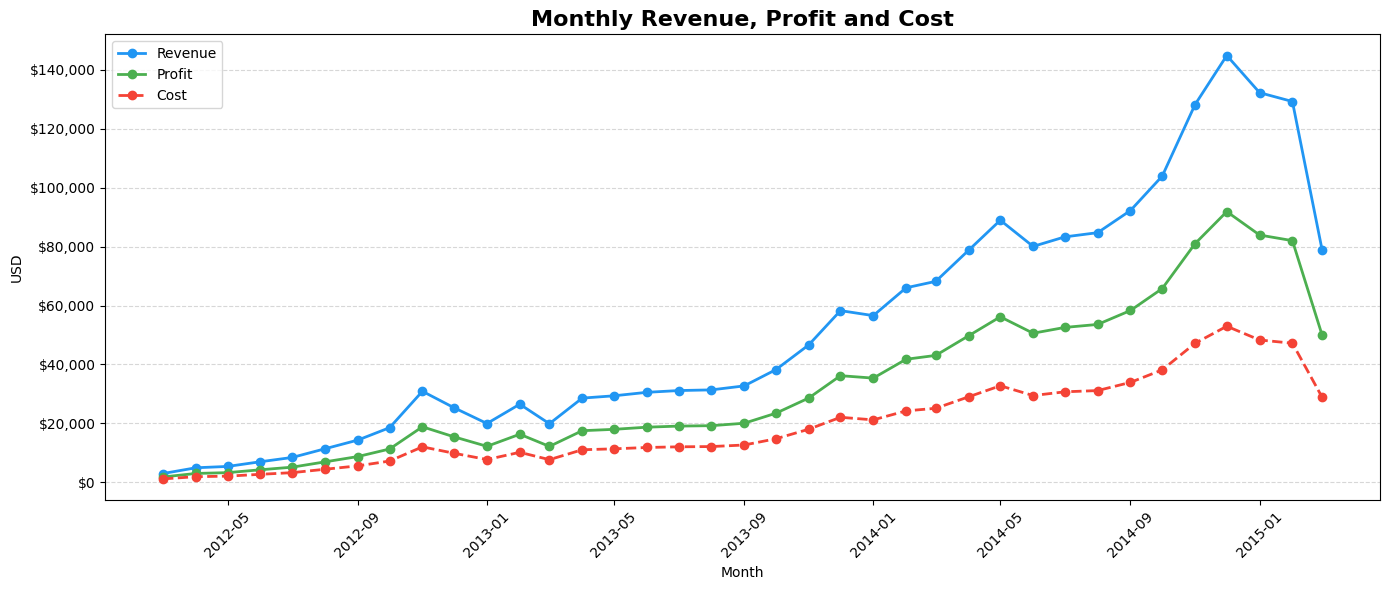

In [7]:
# Plot - Monthly Revenue, Cost and Profit

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_revenue"],
        marker= "o", label = "Revenue", color = "#2196F3", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_profit"],
        marker= "o", label = "Profit",  color = "#4CAF50", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_cost"],
        marker= "o", label = "Cost",    color = "#F44336", linewidth=2, linestyle="--")

ax.set_title("Monthly Revenue, Profit and Cost", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue is growing untill 2015 and declined then sharply. The Profit margin is stable. 

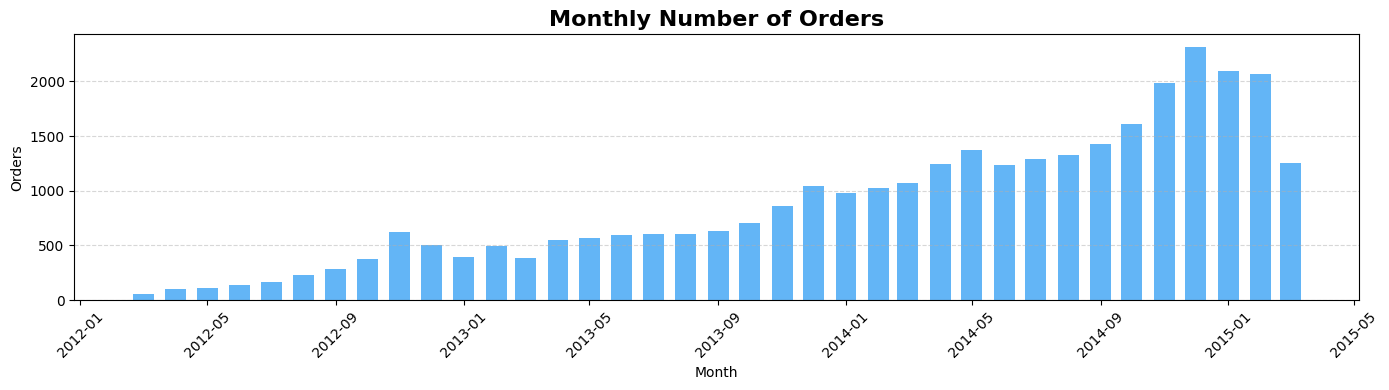

In [15]:
# Plot - Monthly Orders Volume

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(monthly_revenue["year_month_dt"], monthly_revenue["total_orders"], color="#2196F3", alpha=0.7, width=20)

ax.set_title("Monthly Number of Orders", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly order figures have been rising steadily and at an ever-increasing rate since May 2014. Since 2015, monthly order figures have been falling.

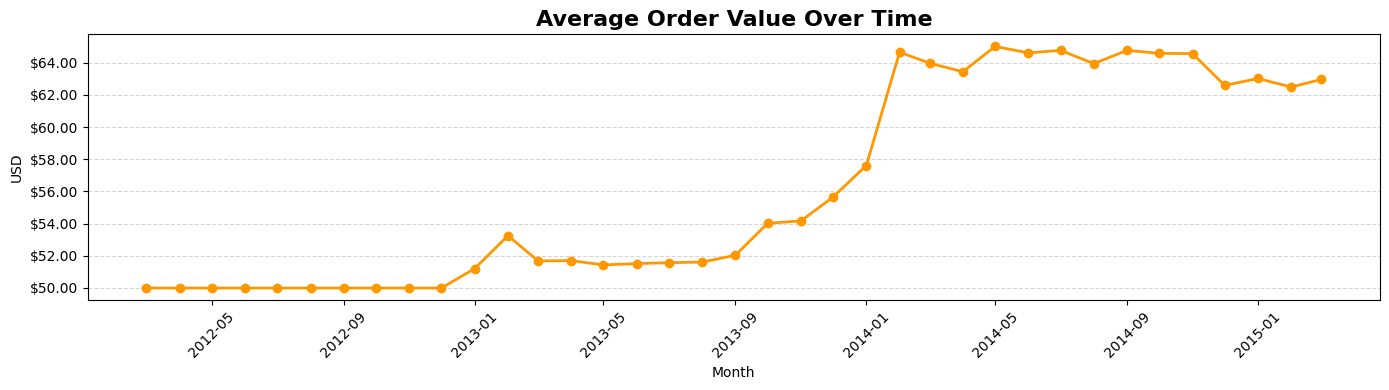

In [16]:
# Plot - Average Order Value over time

monthly_revenue["avg_order_value"] = (monthly_revenue["total_revenue"] / monthly_revenue["total_orders"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["avg_order_value"], marker="o", color="#FF9800", linewidth=2)

ax.set_title("Average Order Value Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary

To begin with, order values rise steadily and gradually. This changes between September 2023 and January 2024, when a sharp increase can be observed. Thereafter, the figures stabilise at a high level.


## Product Analysis

Here I analyse which products drive the most revenue, volume and profit.

In [8]:
product_summary = (df_sales.groupby("product_name").agg(total_revenue = ("price_usd", "sum"), 
                                                     total_cost = ("cogs_usd", "sum"),
                                                     total_profit = ("profit_usd", "sum"), 
                                                     units_sold = ("order_item_id", "count"),
                                                     avg_price = ("price_usd", "mean"))
                    .reset_index()
                    )

product_summary["profit_margin_%"] = ((product_summary["total_profit"] / product_summary["total_revenue"]) * 100).round(2)

product_summary = product_summary.sort_values("total_revenue", ascending=False)

print(product_summary.to_string(index=False))

              product_name  total_revenue  total_cost  total_profit  units_sold  avg_price  profit_margin_%
    The Original Mr. Fuzzy     1211057.74   472164.74      738893.0       24226      49.99            61.01
     The Forever Love Bear      347702.04   130352.04      217350.0        5796      59.99            62.51
  The Birthday Sugar Panda      229260.15    72232.65      157027.5        4985      45.99            68.49
The Hudson River Mini bear      150489.82    47620.82      102869.0        5018      29.99            68.36


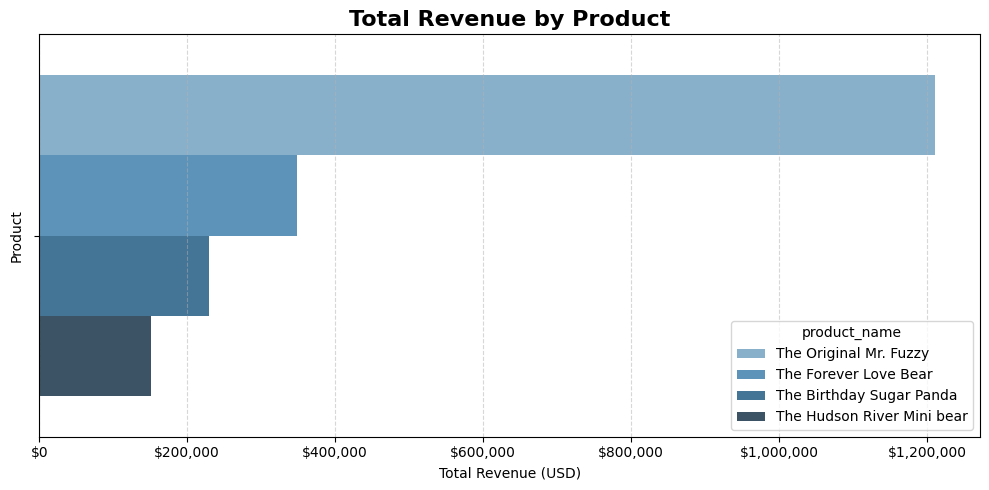

In [13]:
# Plot - Revenue by Product 

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary, x="total_revenue", hue="product_name", palette="Blues_d", ax=ax, legend="auto")

ax.set_title("Total Revenue by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Revenue (USD)")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

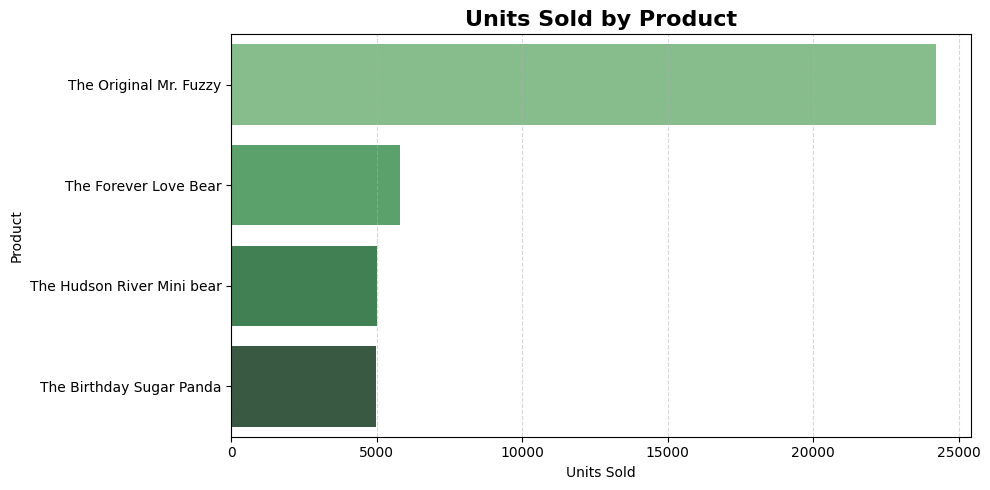

In [16]:
# Plot - Units Sold by Product

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary.sort_values("units_sold", ascending=False), 
            x="units_sold", y="product_name", hue="product_name", palette="Greens_d", ax=ax)

ax.set_title("Units Sold by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Product")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

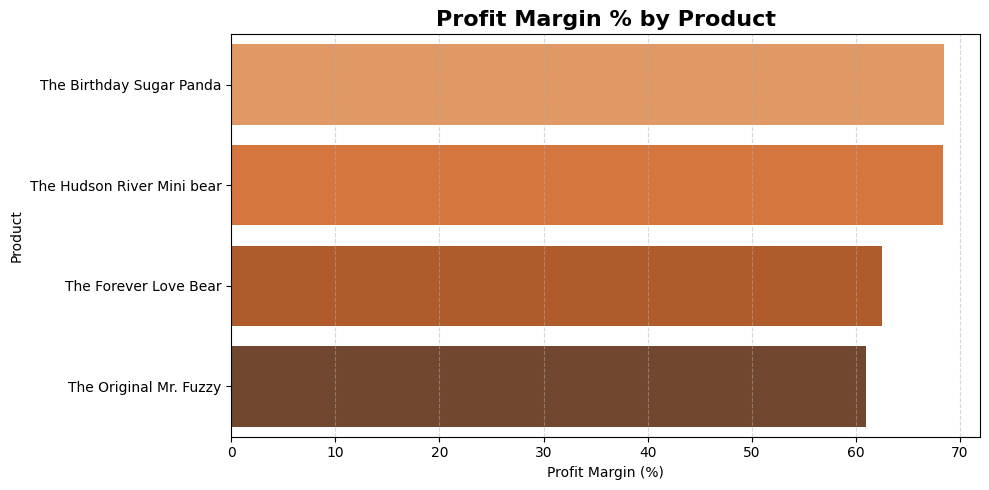

In [17]:
# Plot - Profit Margin by Product

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary.sort_values("profit_margin_%", ascending=False), 
            x="profit_margin_%", y="product_name", hue="product_name", palette="Oranges_d", ax=ax)

ax.set_title("Profit Margin % by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Profit Margin (%)")
ax.set_ylabel("Product")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


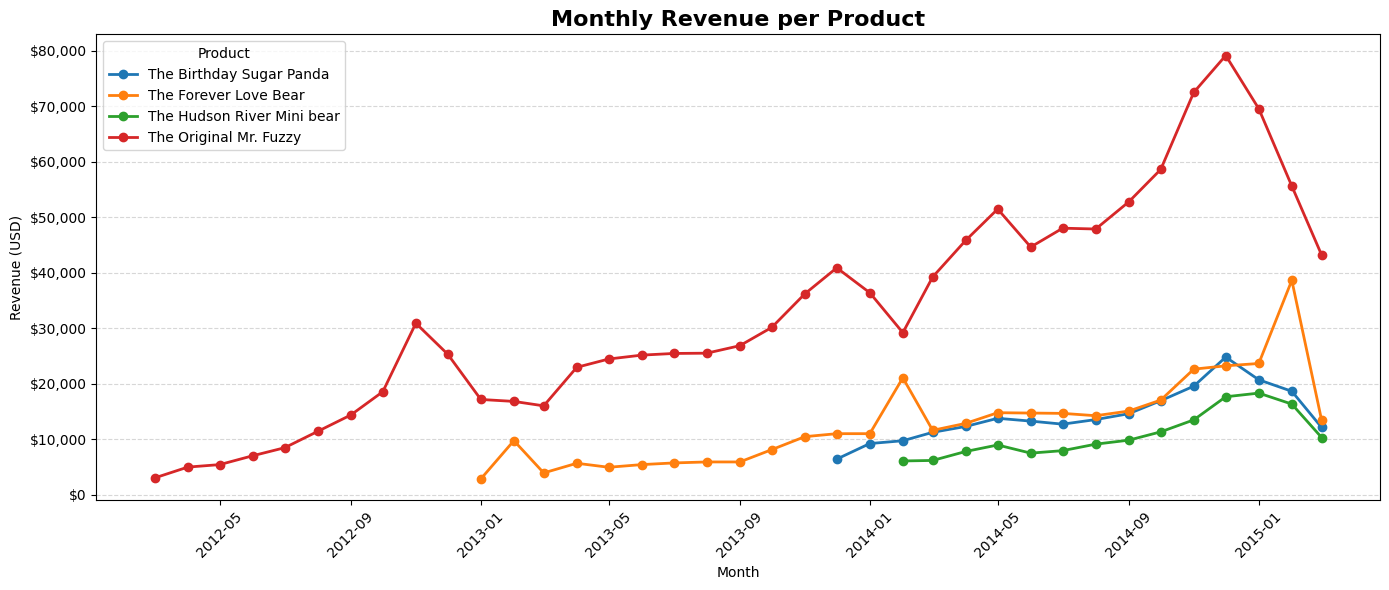

In [18]:
# Plot - Revenue Trend per Product Over Time

product_monthly = (df_sales.groupby(["year_month", "product_name"]).agg(
                total_revenue=("price_usd", "sum")).reset_index()
                )

product_monthly["year_month_dt"] = product_monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

for product, group in product_monthly.groupby("product_name"):
    ax.plot(group["year_month_dt"], group["total_revenue"],
            marker="o", linewidth=2, label=product)

ax.set_title("Monthly Revenue per Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Product")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [20]:

product_summary.style.format({"total_revenue": "${:,.2f}",
                              "total_cost": "${:,.2f}",
                              "total_profit": "${:,.2f}",
                              "avg_price": "${:,.2f}",
                              "profit_margin_%": "{:.1f}%",
                            }).background_gradient(subset=["profit_margin_%"], cmap="Greens")

,product_name,total_revenue,total_cost,total_profit,units_sold,avg_price,profit_margin_%
3,The Original Mr. Fuzzy,"$1,211,057.74","$472,164.74","$738,893.00",24226,$49.99,61.0%
1,The Forever Love Bear,"$347,702.04","$130,352.04","$217,350.00",5796,$59.99,62.5%
0,The Birthday Sugar Panda,"$229,260.15","$72,232.65","$157,027.50",4985,$45.99,68.5%
2,The Hudson River Mini bear,"$150,489.82","$47,620.82","$102,869.00",5018,$29.99,68.4%


### Summary

By far the best-selling product with the highest total revenue is “The Original Mr. Fuzzy” at $1,211,057.74, compared to the total revenue of the remaining products, which amounts to $727,452.01. “The Original Mr. Fuzzy” contributed the most to the total profit, at $738,893.00. Nevertheless, the profit margin is higher for the other products: it stands at 68.4% for “The Birthday Sugar Panda” and “The Hudson River Mini Bear”, compared to 61.0% for “The Original Mr. Fuzzy”.

## Refund Analysis

In this section I analyse which products are being returned most and if it is getting worse over time.

In [27]:

refund_summary = (df_sales.groupby("product_name").agg(
    units_sold = ("order_item_id", "count"), 
    units_refunded  = ("is_refunded", "sum"),
    revenue = ("price_usd", "sum"),
    refund_amount = ("refund_amount_usd","sum")
    )
    .reset_index()
)

refund_summary["refund_rate_%"] = ((refund_summary["units_refunded"]/ refund_summary["units_sold"]) * 100).round(2)

refund_summary["revenue_lost_%"] = ((refund_summary["refund_amount"] / refund_summary["revenue"]) * 100).round(2)

refund_summary = refund_summary.sort_values("refund_rate_%", ascending=False)

print(refund_summary.to_string(index=False))

              product_name  units_sold  units_refunded    revenue  refund_amount  refund_rate_%  revenue_lost_%
  The Birthday Sugar Panda        4985             301  229260.15       13842.99           6.04            6.04
    The Original Mr. Fuzzy       24226            1237 1211057.74       61837.63           5.11            5.11
     The Forever Love Bear        5796             129  347702.04        7738.71           2.23            2.23
The Hudson River Mini bear        5018              64  150489.82        1919.36           1.28            1.28


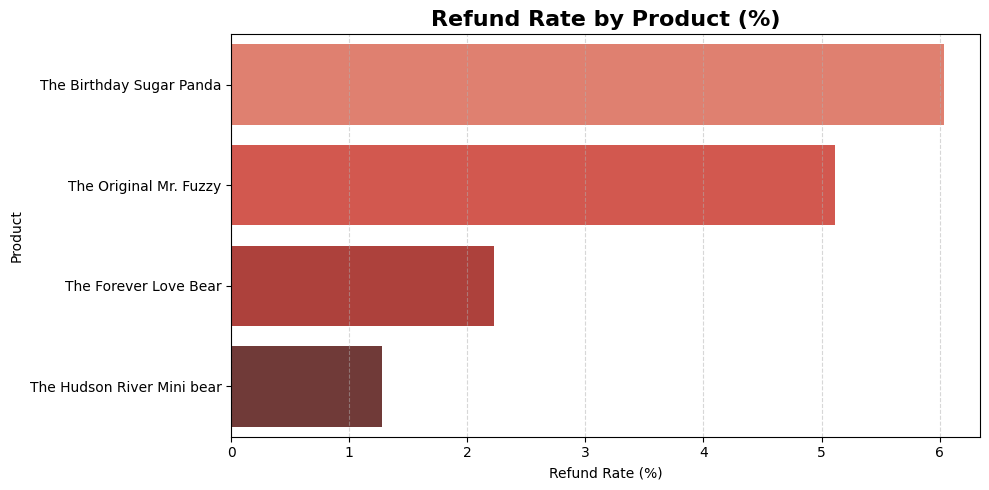

In [ ]:
# Plot - Refund Rate by Product

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=refund_summary, x="refund_rate_%", y="product_name", hue="product_name", palette="Reds_d", ax=ax)

ax.set_title("Refund Rate by Product (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Refund Rate (%)")
ax.set_ylabel("Product")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

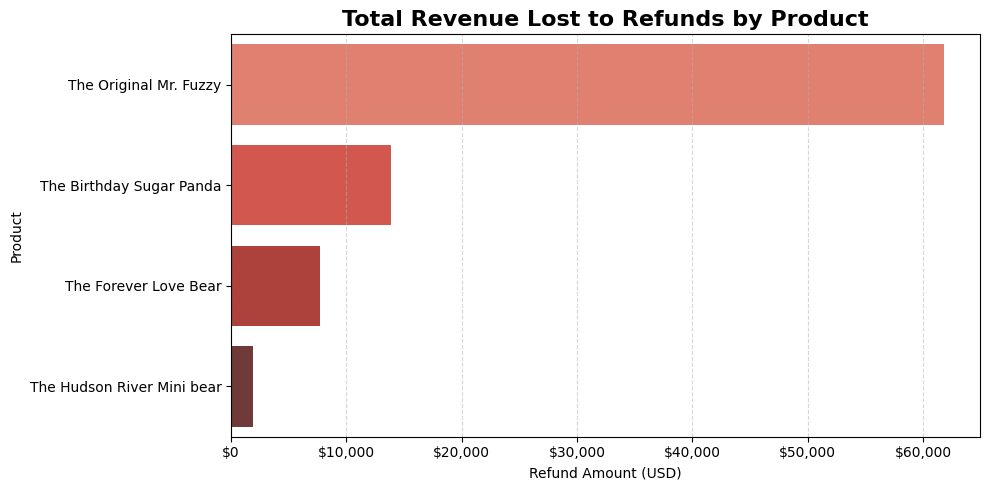

In [ ]:
# Plot - Revenue Lost to Refunds by Product 

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=refund_summary.sort_values("refund_amount", ascending=False), 
            x="refund_amount", y="product_name", hue="product_name", palette="Reds_d", ax=ax)

ax.set_title("Total Revenue Lost to Refunds by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Refund Amount (USD)")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

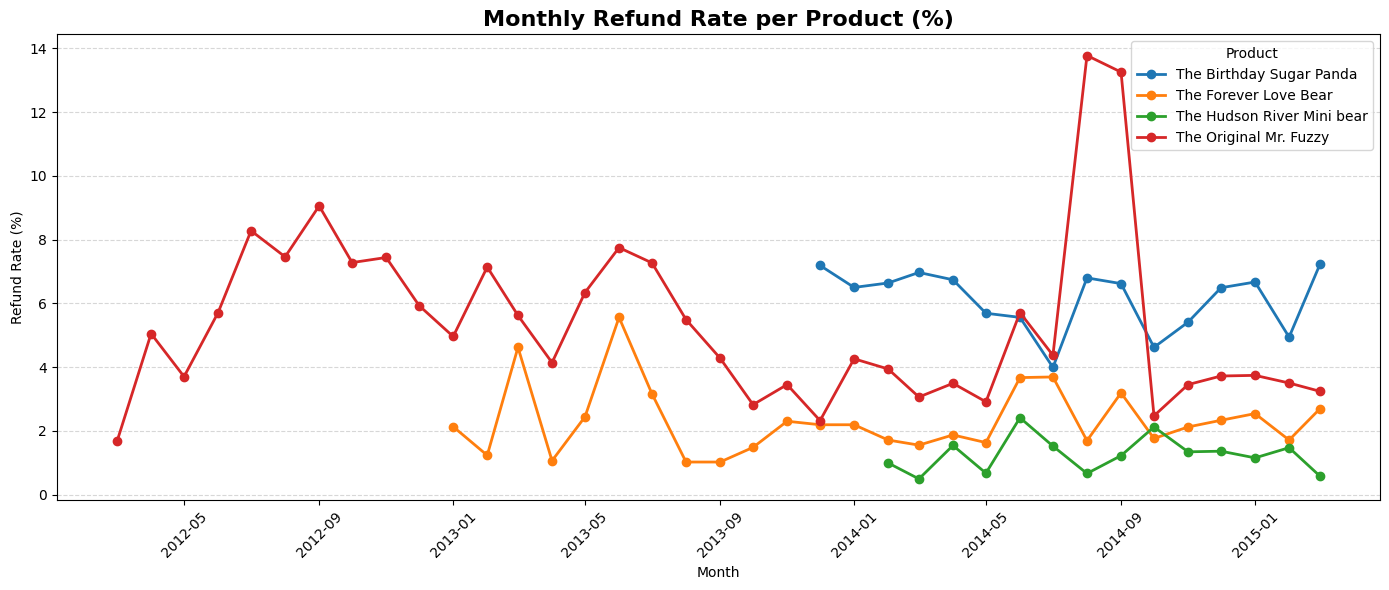

In [31]:
# Plot - Revenue Lost to Refunds by Product

refund_monthly = (df_sales.groupby(["year_month", "product_name"]).agg(units_sold = ("order_item_id", "count"), 
                                                                    units_refunded = ("is_refunded", "sum"))
                                                                    .reset_index()
                 )

refund_monthly["refund_rate_%"]  = ((refund_monthly["units_refunded"] / refund_monthly["units_sold"]) * 100).round(2)

refund_monthly["year_month_dt"] = refund_monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

for product, group in refund_monthly.groupby("product_name"):
    ax.plot(group["year_month_dt"], group["refund_rate_%"],
            marker="o", linewidth=2, label=product)

ax.set_title("Monthly Refund Rate per Product (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Refund Rate (%)")
ax.legend(title="Product")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
overall_refund_rate = (df_sales["is_refunded"].sum() / len(df_sales)) * 100
total_revenue_lost  = df_sales["refund_amount_usd"].sum()

print(f"Overall refund rate: {overall_refund_rate:.2f}%")
print(f"Total revenue lost: ${total_revenue_lost:,.2f}")

Overall refund rate: 4.32%
Total revenue lost: $85,338.69


In [34]:
refund_summary.style.format({"revenue":"${:,.2f}", 
                             "refund_amount":  "${:,.2f}", 
                             "refund_rate_%":  "{:.2f}%", 
                             "revenue_lost_%": "{:.2f}%"}
                             ).background_gradient(
                                 subset=["refund_rate_%"], cmap="Reds")

,product_name,units_sold,units_refunded,revenue,refund_amount,refund_rate_%,revenue_lost_%
0,The Birthday Sugar Panda,4985,301,"$229,260.15","$13,842.99",6.04%,6.04%
3,The Original Mr. Fuzzy,24226,1237,"$1,211,057.74","$61,837.63",5.11%,5.11%
1,The Forever Love Bear,5796,129,"$347,702.04","$7,738.71",2.23%,2.23%
2,The Hudson River Mini bear,5018,64,"$150,489.82","$1,919.36",1.28%,1.28%


### Summary

We can see that "The Birthday Sugar Panda" is losing the most revenue in percentage terms (6.04%). In absolute terms, "The Original Mr. Fuzzy" is in the lead ($1,211,057.74), and it also ranks second in percentage terms (5.11%). "The Hudson River Mini Bear" performs the best, with 1.28%. "The Original Mr. Fuzzy" also has higher monthly fluctuations in its monthly return rate, but has stabilized since September 2013 at just under 4% (with a dramatic outlier in September 2014 at nearly 14%).



## Sessions Analysis

Last but not least I analyse where do visitors come from and which channels actually turn into paying customers.

In [26]:
traffic_summary = (df_sessions.groupby("utm_source").agg(
    total_sessions = ("website_session_id", "count"),
    conversions = ("converted", "sum"),
    orders = ("order_id", "nunique"))
    .reset_index())

traffic_summary["conversion_rate_%"] = ((traffic_summary["conversions"] / traffic_summary["total_sessions"]) * 100).round(2)

traffic_summary = traffic_summary.sort_values("total_sessions", ascending=False)

print(traffic_summary.to_string(index=False))

utm_source  total_sessions  conversions  orders  conversion_rate_%
   gsearch          316035        21333   21333               6.75
   bsearch           62823         4519    4519               7.19
socialbook           10685          343     343               3.21


In [31]:
# In order to get a connection between revenue and session I do a new merge

orders_df = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/4_orders_clean.csv")
orders_df["created_at"] = pd.to_datetime(orders_df["created_at"])

sessions_revenue = pd.merge(df_sessions, orders_df[["order_id", "price_usd", "cogs_usd"]], on="order_id", how="left")

revenue_by_source = (sessions_revenue.groupby("utm_source").agg(
    total_revenue = ("price_usd", "sum"),
    total_cost = ("cogs_usd",  "sum"))
    .reset_index())


revenue_by_source["total_profit"] = (revenue_by_source["total_revenue"] - revenue_by_source["total_cost"])

traffic_summary = pd.merge(traffic_summary, revenue_by_source, on="utm_source", how="left")

traffic_summary["revenue_per_session"] = (traffic_summary["total_revenue"] / traffic_summary["total_sessions"]).round(2)

print(traffic_summary.to_string(index=False))

utm_source  total_sessions  conversions  orders  conversion_rate_%  total_revenue  total_cost  total_profit  revenue_per_session
   gsearch          316035        21333   21333               6.75     1276144.89   475986.39      800158.5                 4.04
   bsearch           62823         4519    4519               7.19      268672.50   100238.50      168434.0                 4.28
socialbook           10685          343     343               3.21       22259.33     8156.83       14102.5                 2.08


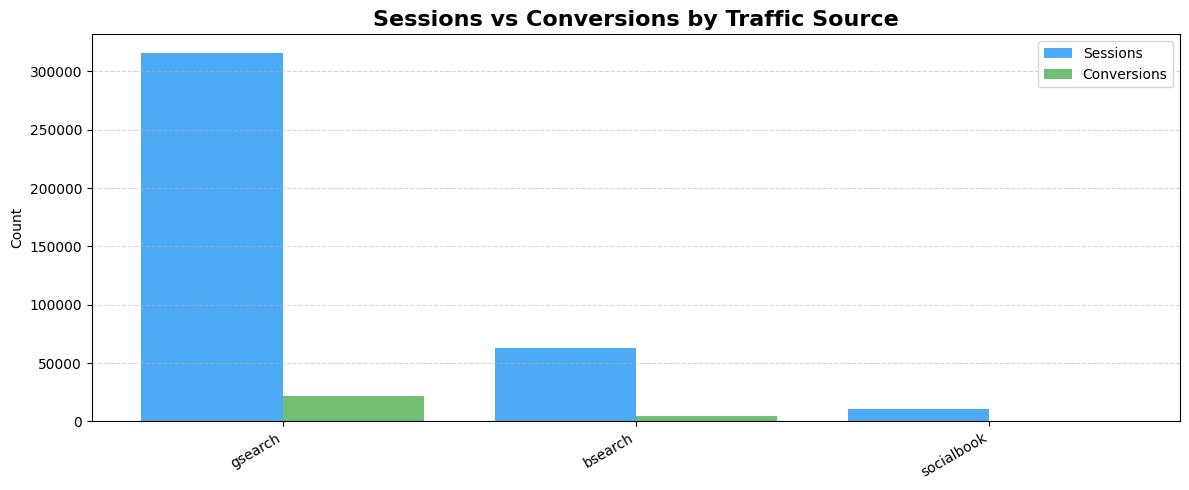

In [32]:
#Plot - Sessions vs Conversions by Source

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(traffic_summary))
width = 0.4

ax.bar([i - width/2 for i in x], traffic_summary["total_sessions"], width=width, label="Sessions", color="#2196F3", alpha=0.8)
ax.bar([i + width/2 for i in x], traffic_summary["conversions"], width=width, label="Conversions", color="#4CAF50", alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(traffic_summary["utm_source"], rotation=30, ha="right")
ax.set_title("Sessions vs Conversions by Traffic Source", fontsize=16, fontweight="bold")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

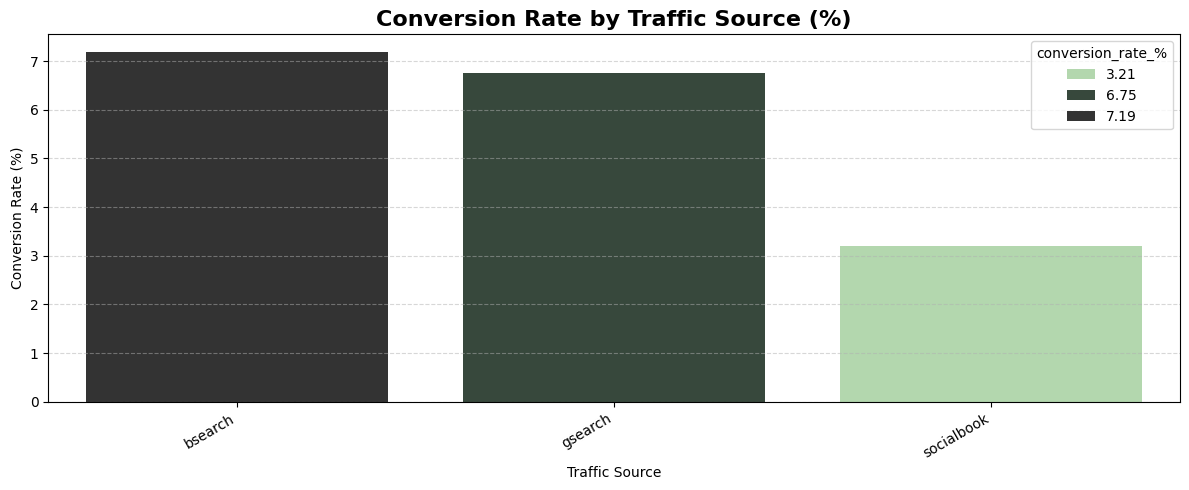

In [ ]:
#Plot - Conversion Rate by Traffic Source

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(data=traffic_summary.sort_values("conversion_rate_%", ascending=False), x="utm_source", 
            y="conversion_rate_%", hue= "conversion_rate_%", palette="Greens_d", ax=ax)

ax.set_title("Conversion Rate by Traffic Source (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Traffic Source")
ax.set_ylabel("Conversion Rate (%)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

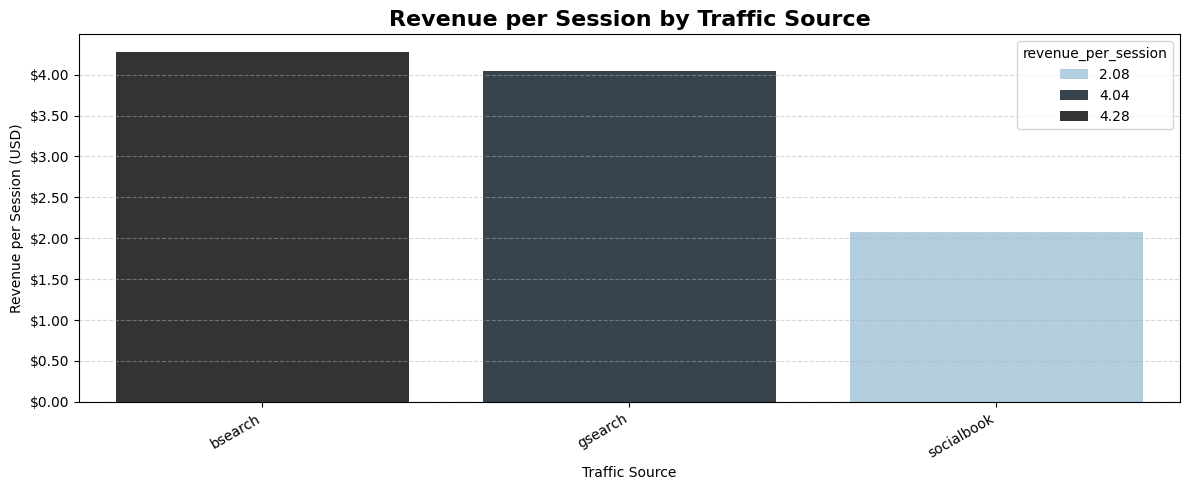

In [34]:
# Plot - Revenue per Session by Source

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(data=traffic_summary.sort_values("revenue_per_session", ascending=False), 
            x="utm_source", y="revenue_per_session", hue= "revenue_per_session", palette="Blues_d", ax=ax) 

ax.set_title("Revenue per Session by Traffic Source", fontsize=16, fontweight="bold")
ax.set_xlabel("Traffic Source")
ax.set_ylabel("Revenue per Session (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



device_type  total_sessions  conversions  conversion_rate_%
    desktop          327027        27805               8.50
     mobile          145844         4508               3.09


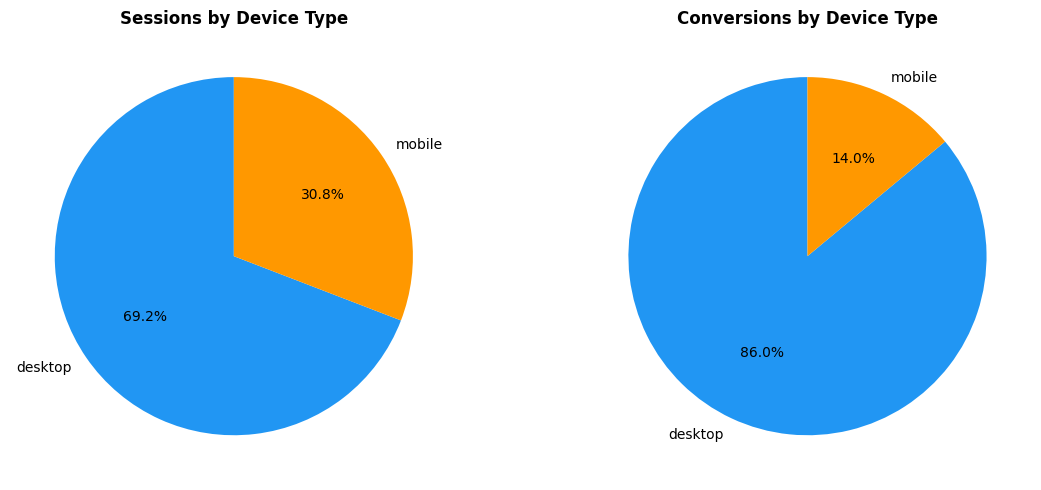

In [36]:
# Plot - Device Type Breakdown

device_summary = (df_sessions.groupby("device_type").agg(
    total_sessions = ("website_session_id", "count"),
    conversions = ("converted", "sum"))
    .reset_index()
    )

device_summary["conversion_rate_%"] = ((device_summary["conversions"] / device_summary["total_sessions"]) * 100).round(2)

print(device_summary.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(device_summary["total_sessions"],
            labels=device_summary["device_type"],
            autopct="%1.1f%%",
            colors=["#2196F3", "#FF9800"],
            startangle=90)
axes[0].set_title("Sessions by Device Type", fontweight="bold")

axes[1].pie(device_summary["conversions"],
            labels=device_summary["device_type"],
            autopct="%1.1f%%",
            colors=["#2196F3", "#FF9800"],
            startangle=90)
axes[1].set_title("Conversions by Device Type", fontweight="bold")

plt.tight_layout()
plt.show()



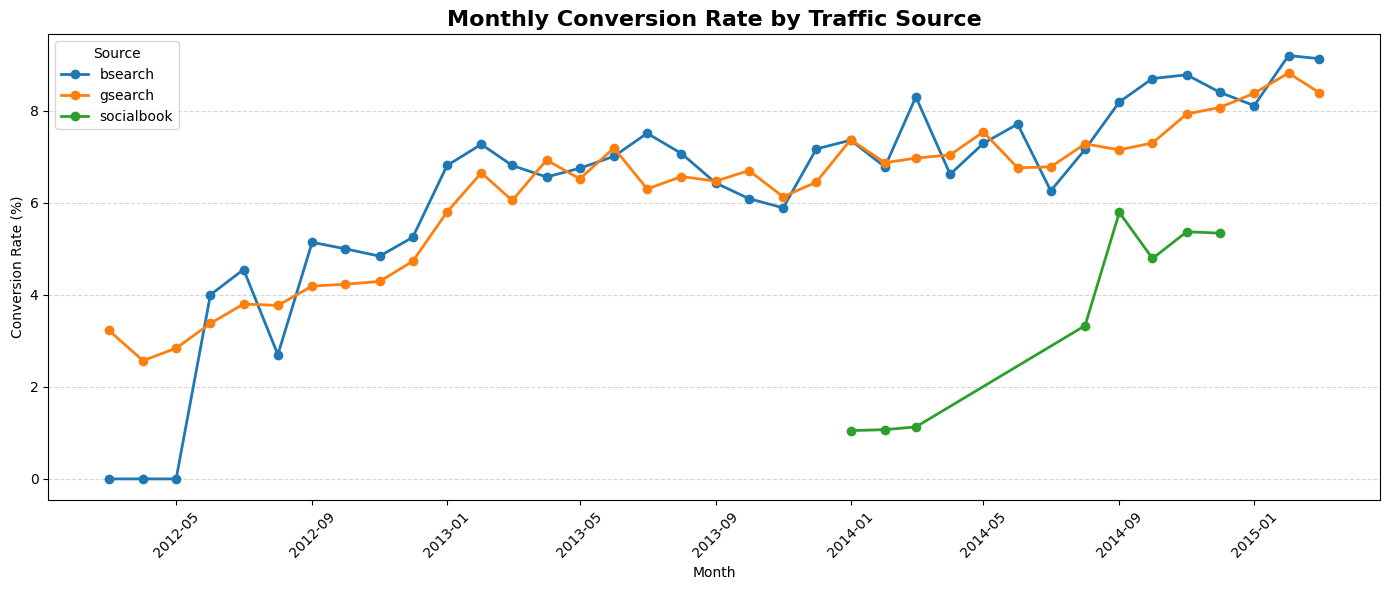

In [38]:
# Plot - Conversion Rate Trend Over Time by Top Source

df_sessions["created_at"] = pd.to_datetime(df_sessions["created_at"])
df_sessions["year_month"] = df_sessions["created_at"].dt.to_period("M")


df_sessions["year_month"]    = df_sessions["created_at"].dt.to_period("M")
df_sessions["year_month_dt"] = df_sessions["year_month"].dt.to_timestamp()

monthly_conversion = (
    df_sessions.groupby(["year_month_dt", "utm_source"]).agg(
        total_sessions = ("website_session_id", "count"),
        conversions = ("converted",          "sum"))
        .reset_index()
        )

monthly_conversion["conversion_rate_%"] = ((monthly_conversion["conversions"] / monthly_conversion["total_sessions"]) * 100).round(2)

# Only plot top 4 sources by total sessions to keep chart readable
top_sources = traffic_summary.nlargest(4, "total_sessions")["utm_source"].tolist()
monthly_conversion_top = monthly_conversion[monthly_conversion["utm_source"].isin(top_sources)]

fig, ax = plt.subplots(figsize=(14, 6))

for source, group in monthly_conversion_top.groupby("utm_source"):
    ax.plot(group["year_month_dt"], group["conversion_rate_%"],
            marker="o", linewidth=2, label=source)

ax.set_title("Monthly Conversion Rate by Traffic Source", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Conversion Rate (%)")
ax.legend(title="Source")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary

"bsearch" and "gsearch" are the main drivers of the monthly conversion rate and also generate the most revenue.